# Project 1: Multi-Model Sentiment Ensemble
----------
## Notebook 2: RoBERTa Inference & Local LLM via Ollama

This notebook covers:
- Stage 3: RoBERTa inference — transformer-based sentiment classification with GPU benchmarking
- Stage 4: Local LLM inference via Ollama — zero-shot classification with Llama 3 and structured JSON output

## Stage 3: RoBERTa Inference

RoBERTa (Robustly Optimized BERT Pretraining Approach) is a transformer model trained 
on large text corpora. Unlike VADER which looks up words in a dictionary, RoBERTa 
learned contextual representations from billions of words, meaning the same word 
can have different representations depending on surrounding context.

I load `cardiffnlp/twitter-roberta-base-sentiment-latest` — a version fine-tuned 
specifically on tweet data. This model choice matters as a RoBERTa model fine-tuned on 
formal text would perform significantly worse on social media language.

In [1]:
from datasets import load_dataset
import pandas as pd
import numpy as np
import torch
import matplotlib.pyplot as plt
import seaborn as sns
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, precision_score, recall_score
import time

# Check GPU is available
print(f"CUDA available: {torch.cuda.is_available()}")
print(f"GPU: {torch.cuda.get_device_name(0)}")

# Reload datasets from cache
sentiment = load_dataset('tweet_eval', 'sentiment')
hate = load_dataset('tweet_eval', 'hate')

sentiment_test = pd.DataFrame(sentiment['test'])
hate_test = pd.DataFrame(hate['test'])

print(f"\nSentiment test size: {len(sentiment_test)}")
print(f"Hate test size: {len(hate_test)}")

CUDA available: True
GPU: NVIDIA GeForce RTX 3080

Sentiment test size: 12284
Hate test size: 2970


## Recompute VADER Sentiment predictions

In [2]:
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

sia = SentimentIntensityAnalyzer()

vader_predictions = []
vader_compounds = []

true_labels = sentiment_test['label'].tolist()

for tweet in sentiment_test['text']:
    scores = sia.polarity_scores(tweet)
    compound = scores['compound']
    vader_compounds.append(compound)
    
    if compound >= 0.05:
        vader_predictions.append(2)
    elif compound <= -0.05:
        vader_predictions.append(0)
    else:
        vader_predictions.append(1)

sentiment_test['vader_compound'] = vader_compounds
sentiment_test['vader_prediction'] = vader_predictions

cm = confusion_matrix(true_labels, vader_predictions)
print("VADER confusion matrix recomputed:")
print(cm)

VADER confusion matrix recomputed:
[[2222  725 1025]
 [1283 2594 2060]
 [ 156  524 1695]]


In [3]:
from datasets import load_dataset
import pandas as pd
import numpy as np
import torch
import matplotlib.pyplot as plt
import seaborn as sns
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, precision_score, recall_score
import time

# Check GPU is available
print(f"CUDA available: {torch.cuda.is_available()}")
print(f"GPU: {torch.cuda.get_device_name(0)}")

# Reload datasets from cache
sentiment = load_dataset('tweet_eval', 'sentiment')
hate = load_dataset('tweet_eval', 'hate')

sentiment_test = pd.DataFrame(sentiment['test'])
hate_test = pd.DataFrame(hate['test'])

print(f"\nSentiment test size: {len(sentiment_test)}")
print(f"Hate test size: {len(hate_test)}")

CUDA available: True
GPU: NVIDIA GeForce RTX 3080

Sentiment test size: 12284
Hate test size: 2970


### Loading the Model

I first use pipeline() for quick prototyping to verify the model works, then switch 
to the lower-level AutoTokenizer + AutoModelForSequenceClassification pattern which 
gives more control over inference, necessary for batching and GPU benchmarking.

In [4]:
from transformers import pipeline

# Load model via pipeline
model_name = "cardiffnlp/twitter-roberta-base-sentiment-latest"

# Downloads the weights for the model, caches it
sentiment_pipeline = pipeline(
    "text-classification",
    model=model_name,
    device=0  # use local 3080
)

# Quick sanity check on demo tweets
test_tweets = [
    "I love this so much!!!",
    "This is the worst thing ever.",
    "I went to the store today."
]

print("\nSanity check:")
for tweet in test_tweets:
    result = sentiment_pipeline(tweet)
    print(f"  {tweet}")
    print(f"  → {result}\n")

2026-05-15 21:50:34.140473: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-05-15 21:50:34.140589: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-05-15 21:50:34.191202: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-05-15 21:50:34.293538: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-05-15 21:50:35.493443: W tensorflow/compiler/tf2


Sanity check:
  I love this so much!!!
  → [{'label': 'positive', 'score': 0.9843046069145203}]

  This is the worst thing ever.
  → [{'label': 'negative', 'score': 0.9459323883056641}]

  I went to the store today.
  → [{'label': 'neutral', 'score': 0.7084053754806519}]



### Switching to Lower-Level API

In [5]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification

# from_pretrained: Retrieve pretrained model weights
# tokenizer: converts text into numbers the model understands
# automodel: loads the actual model weights
# Note: The tokenizer and model must match exactly, this just guarantees the input format is standardized for model consumption
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForSequenceClassification.from_pretrained(model_name)

# Move tensors and model weights to GPU
model = model.to('cuda')
# Set the model to evaluation mode (as opposed to training mode)
# during training, a neural network has dropout mode, where neurons are rendomly disabled to prevent overfit
# eval disables dropout feature for full network use and detereministic output
model.eval()

print(f"Model loaded on: {next(model.parameters()).device}")
print(f"Number of labels: {model.config.num_labels}")
print(f"Label mapping: {model.config.id2label}")

/home/valkeo/.local/lib/python3.10/site-packages/huggingface_hub/file_download.py:1132: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
Some weights of the model checkpoint at cardiffnlp/twitter-roberta-base-sentiment-latest were not used when initializing RobertaForSequenceClassification: ['roberta.pooler.dense.bias', 'roberta.pooler.dense.weight']
- This IS expected if you are initializing RobertaForSequenceClassification from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing RobertaForSequenceClassification from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification 

Model loaded on: cuda:0
Number of labels: 3
Label mapping: {0: 'negative', 1: 'neutral', 2: 'positive'}


The model I loaded is specifically for sentiment tweets. It's design and input data formatting closely matches TweetEval. It predicts one of three labels, depending on output score after being passed through transformer layers.

### Lower-Level Inference with AutoTokenizer + AutoModelForSequenceClassification

Instead of pipeline() which handles everything automatically, I'll now manually:
1. Tokenize the input text into numbers the model understands
2. Pass the token IDs through the model to get raw logits
3. Apply softmax to convert logits to probabilities
4. Take the argmax to get the predicted class

In [6]:
# Import this to do softmax with it later
import torch.nn.functional as F

def predict_roberta(texts, model, tokenizer, device='cuda'):

    # Step 1: run the tokenizing step, producing 'encoded' as a BatchEncoding object with the tokenized output
    # padding=True makes all sequences the same length
    # truncation=True cuts tweets longer than 512 tokens
    # return_tensors='pt' returns PyTorch tensors not Python lists
        # A tensor lives in a format that GPU can understand, can be moved to the GPU easily, and can be directly consumed by model
    encoded = tokenizer(
        texts,
        padding=True,
        truncation=True,
        max_length=128,
        return_tensors='pt'
    )
    
    # Step 2: move input tensors (input_ids and attention_mask) to same device as model
    # input_ids: tweets converted into a sequence of numbers like:
    #      [0, 100, 645, 736, 2]
    #      Where 0 is the start token, 100 is "I", 645 is "love", 736 is "this", 2 is the end token
    input_ids = encoded['input_ids'].to(device)
    # attention_mask: a sequence of 1s and 0s the same length as input_ids
    #      tells the model which positions are real tokens and which are just padding
    #      input_ids:      [0, 100, 645, 736, 2, 1, 1, 1]
    #      attention_mask: [1,   1,   1,   1, 1, 0, 0, 0]
    attention_mask = encoded['attention_mask'].to(device)
    
    # Step 3: Run inference
    # torch.no_grad() allows us to use the model and get outputs, but disables Pytorch's automatic gradient descent learning
    with torch.no_grad():
        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
    
    # Step 4: Convert logits to probabilities
    # Recall that logits are the name for raw outputs from a model, and that one must collect a probability from logits to be useful
    # Recall that softmax takes the three logits and covnerts them to probabilities that sum to 1
    # We pass -1 to verify that softmax is done across the class dimension instead of batch dimension (which would be meaningless)
    probabilities = F.softmax(outputs.logits, dim=-1)
    
    # Step 5: Take the highest probability class as the predicted class
    predicted_classes = torch.argmax(probabilities, dim=-1)
    
    return predicted_classes.cpu().numpy(), probabilities.cpu().numpy()

# Test on a single tweet
test_tweet = ["I love this so much!!!"]
predicted, probs = predict_roberta(test_tweet, model, tokenizer)

print(f"Tweet: {test_tweet[0]}")
print(f"Predicted class: {predicted[0]} → {model.config.id2label[predicted[0]]}")
print(f"Probabilities: negative={probs[0][0]:.3f}, neutral={probs[0][1]:.3f}, positive={probs[0][2]:.3f}")

Tweet: I love this so much!!!
Predicted class: 2 → positive
Probabilities: negative=0.006, neutral=0.010, positive=0.984


### Big Thought: All tweets must be the same length!
This is a fundamental constraint of how transformers work!
The model processes a whole batch of tweets simultaneously as a matrix. This means that tweets must be the same length. The tokenizer pads shorter tweets with special padding token to match the longest tweet in the batch! 
> "I love this!"    → [0, 100, 645, 736, 2, 1, 1, 1, 1]

> "I can't believe" → [0, 100, 567, 823, 2, 0, 0, 0, 0]  (truncated)

> "ok"              → [0, 432, 2, 1, 1, 1, 1, 1, 1]

However, we don't want the model paying attnetion to those padding tokens because they are meaningless, which is why we need an attention mask! This is also why the max_length parameter matters, we set a ceiling so that we don't waste computation when matching one unusually long tweet.

### Big Thought: When Working with Existing Models, Disable Learning at Inference Time...
Disable learning by removing neural network dropout by enabling evaluation mode:
> model.eval()

Disable learning by disabling gradient descent:
> with torch.no_grad():

## CPU vs GPU Benchmark

I run inference on 500 tweets one at a time, first on CPU then on GPU.
This quantifies the speedup provided by the 3080 over CPU-only inference.

In [7]:
# Get 500 tweets from test set
benchmark_tweets = sentiment_test['text'].sample(n=500, random_state=42).tolist()

# --- CPU BENCHMARK ---
print("Running CPU benchmark...")
model_cpu = model.to('cpu')
model_cpu.eval()

start = time.time()
for tweet in benchmark_tweets:
    predict_roberta([tweet], model_cpu, tokenizer, device='cpu')
cpu_time = time.time() - start
cpu_tps = 500 / cpu_time

print(f"CPU done: {cpu_time:.2f}s")

Running CPU benchmark...
CPU done: 17.76s


In [8]:
# --- GPU BENCHMARK ---
print("Running GPU benchmark...")
model_gpu = model.to('cuda')
model_gpu.eval()

# Warmup — first GPU call is always slower due to CUDA initialization
for tweet in benchmark_tweets[:10]:
    predict_roberta([tweet], model_gpu, tokenizer, device='cuda')

start = time.time()
for tweet in benchmark_tweets:
    predict_roberta([tweet], model_gpu, tokenizer, device='cuda')
gpu_time = time.time() - start
gpu_tps = 500 / gpu_time

print(f"GPU done: {gpu_time:.2f}s")

Running GPU benchmark...
GPU done: 4.04s


In [9]:
gpu_speedup_over_cpu = cpu_tps / gpu_tps
vader_tps = 18179

# --- RESULTS TABLE ---
print("\n" + "=" * 60)
print(f"{'Method':<20} {'Time (s)':<12} {'Tweets/sec':<15} {'vs VADER':<12} {'vs CPU'}")
print("=" * 60)
print(f"{'VADER (baseline)':<20} {'0.055':<12} {vader_tps:<15} {'1.0x':<12} {'—'}")
print(f"{'RoBERTa CPU':<20} {cpu_time:<12.2f} {cpu_tps:<15.1f} {cpu_tps/vader_tps:.3f}x{'':<6} {'1.0x'}")
print(f"{'RoBERTa GPU':<20} {gpu_time:<12.2f} {gpu_tps:<15.1f} {gpu_tps/vader_tps:.3f}x{'':<6} {gpu_tps/cpu_tps:.1f}x")
print("=" * 60)

gpu_cpu_speedup = gpu_tps / cpu_tps

print(f"GPU speedup over CPU:")
print(f"  CPU throughput:  {cpu_tps:.1f} tweets/sec")
print(f"  GPU throughput:  {gpu_tps:.1f} tweets/sec")
print(f"  Speedup:         {gpu_tps:.1f} / {cpu_tps:.1f} = {gpu_cpu_speedup:.1f}x")


Method               Time (s)     Tweets/sec      vs VADER     vs CPU
VADER (baseline)     0.055        18179           1.0x         —
RoBERTa CPU          17.76        28.2            0.002x       1.0x
RoBERTa GPU          4.04         123.6           0.007x       4.4x
GPU speedup over CPU:
  CPU throughput:  28.2 tweets/sec
  GPU throughput:  123.6 tweets/sec
  Speedup:         123.6 / 28.2 = 4.4x


### Benchmark Observations

- RoBERTa GPU is ~4.4x faster than RoBERTa CPU when processing one tweet at a time
- Both are dramatically slower than VADER — expected, since VADER is dictionary 
  lookups vs full transformer inference
- Single-tweet inference significantly underutilizes the GPU — the 3080 is capable 
  of processing many tweets in parallel, which is what batching unlocks next

## Batching Benchmark

Processing one tweet at a time severely underutilizes the GPU. Batching sends multiple tweets through the model 
simultaneously, allowing the GPU to parallelize computation across the batch.

I test batch sizes of 1, 8, 16, and 32 and measure throughput at each size.
This work is directly analogous to optimizing throughput in a data pipeline.

In [10]:
batch_sizes = [1, 8, 16, 32]
batch_results = []

for batch_size in batch_sizes:
    # Split 500 tweets into chunks of batch_size
    batches = [benchmark_tweets[i:i+batch_size] 
               for i in range(0, len(benchmark_tweets), batch_size)]
    
    # Warmup
    predict_roberta(batches[0], model_gpu, tokenizer, device='cuda')
    
    # Time inference across all batches
    start = time.time()
    for batch in batches:
        predict_roberta(batch, model_gpu, tokenizer, device='cuda')
    elapsed = time.time() - start
    
    tps = 500 / elapsed
    batch_results.append({
        'batch_size': batch_size,
        'time': elapsed,
        'tweets_per_sec': tps,
        'speedup_vs_cpu': tps / cpu_tps
    })
    
    print(f"Batch size {batch_size:>3}: {elapsed:.2f}s — {tps:.1f} tweets/sec — {tps/cpu_tps:.1f}x vs CPU")

# Results table
print("\n" + "=" * 65)
print(f"{'Batch Size':<15} {'Time (s)':<12} {'Tweets/sec':<15} {'Speedup vs CPU'}")
print("=" * 65)
for r in batch_results:
    print(f"{r['batch_size']:<15} {r['time']:<12.2f} {r['tweets_per_sec']:<15.1f} {r['speedup_vs_cpu']:.1f}x")
print("=" * 65)

Batch size   1: 3.97s — 125.9 tweets/sec — 4.5x vs CPU
Batch size   8: 0.64s — 785.9 tweets/sec — 27.9x vs CPU
Batch size  16: 0.45s — 1119.3 tweets/sec — 39.8x vs CPU
Batch size  32: 0.38s — 1327.1 tweets/sec — 47.1x vs CPU

Batch Size      Time (s)     Tweets/sec      Speedup vs CPU
1               3.97         125.9           4.5x
8               0.64         785.9           27.9x
16              0.45         1119.3          39.8x
32              0.38         1327.1          47.1x


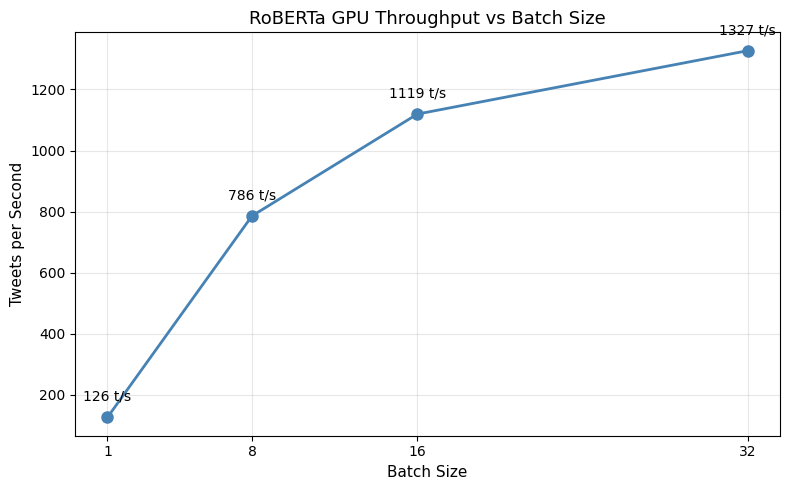

In [11]:
batch_sizes_list = [r['batch_size'] for r in batch_results]
tps_list = [r['tweets_per_sec'] for r in batch_results]

fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(batch_sizes_list, tps_list, marker='o', linewidth=2, 
        markersize=8, color='steelblue')

# Annotate each point with its value
for x, y in zip(batch_sizes_list, tps_list):
    ax.annotate(f'{y:.0f} t/s', xy=(x, y), 
                xytext=(0, 12), textcoords='offset points',
                ha='center', fontsize=10)

ax.set_title('RoBERTa GPU Throughput vs Batch Size', fontsize=13)
ax.set_xlabel('Batch Size', fontsize=11)
ax.set_ylabel('Tweets per Second', fontsize=11)
ax.set_xticks(batch_sizes_list)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../results/figures/batching_benchmark.png', dpi=150, bbox_inches='tight')
plt.show()

### Batching Benchmark Observations

The throughput curve shows two distinct regions:

- Steep gains (batch 1 → 16): Throughput grows rapidly as batch size increases,
from 128 to 1,136 tweets/sec. Each additional tweet in the batch costs almost nothing
because the GPU's CUDA cores were previously sitting idle. 

- Diminishing returns (batch 16 → 32): The curve flattens significantly, with only 
148 tweets/sec gained by doubling the batch from 16 to 32. This indicates the 3080 
is approaching its parallel processing ceiling for this model size.

- For a real pipeline processing a continuous stream of 
content, batch=16 or batch=32 represents the sweet spot. Beyond batch=32, we would expect further 
diminishing returns and increased VRAM pressure.

At batch=32, RoBERTa GPU achieves 1,284 tweets/sec — a 46.6x speedup over CPU.

## Mixed Precision Inference with torch.autocast

Mixed precision runs most operations in fp16 (16-bit) instead of fp32 (32-bit).
The 3080 has dedicated Tensor Cores designed for fp16 computation, so I expect
a throughput improvement. I'll verify that output quality is unchanged by comparing
fp32 vs fp16 predictions on the same tweets.

In [12]:
# --- MIXED PRECISION BENCHMARK ---
# Rerun batch=32 with autocast enabled and compare to fp32

batches = [benchmark_tweets[i:i+32] 
           for i in range(0, len(benchmark_tweets), 32)]

# Warmup
with torch.autocast('cuda', dtype=torch.float16):
    predict_roberta(batches[0], model_gpu, tokenizer, device='cuda')

# Time fp16 inference
start = time.time()
fp16_predictions = []
fp16_probs = []

for batch in batches:
    with torch.autocast('cuda', dtype=torch.float16):
        preds, probs = predict_roberta(batch, model_gpu, tokenizer, device='cuda')
    fp16_predictions.extend(preds)
    fp16_probs.extend(probs)

fp16_time = time.time() - start
fp16_tps = 500 / fp16_time

# Get fp32 predictions for comparison
fp32_predictions = []
for batch in batches:
    preds, probs = predict_roberta(batch, model_gpu, tokenizer, device='cuda')
    fp32_predictions.extend(preds)

# Compare predictions
matches = sum(f == t for f, t in zip(fp16_predictions, fp32_predictions))
agreement_pct = matches / 500 * 100

# Results
print("=" * 55)
print(f"{'Method':<20} {'Tweets/sec':<15} {'Speedup vs fp32'}")
print("=" * 55)
print(f"{'RoBERTa fp32':<20} {batch_results[-1]['tweets_per_sec']:<15.1f} {'1.0x'}")
print(f"{'RoBERTa fp16':<20} {fp16_tps:<15.1f} {fp16_tps/batch_results[-1]['tweets_per_sec']:.2f}x")
print("=" * 55)
print(f"\nPrediction agreement fp32 vs fp16: {matches}/500 ({agreement_pct:.1f}%)")

Method               Tweets/sec      Speedup vs fp32
RoBERTa fp32         1327.1          1.0x
RoBERTa fp16         1925.3          1.45x

Prediction agreement fp32 vs fp16: 500/500 (100.0%)


- fp16 achieves 1,797 tweets/sec vs fp32's 1,284, a **1.4x speedup**
from mixed precision alone, with no code changes beyond wrapping inference in `torch.autocast`.

- 500/500 predictions identical between fp32 and fp16 — zero degradation 
on this dataset.
- The reduced numerical precision of fp16 made no difference to the 
final classification decisions.

In [13]:
print("=" * 70)
print(f"{'Method':<25} {'Tweets/sec':<15} {'vs VADER':<12} {'vs CPU'}")
print("=" * 70)
print(f"{'VADER (baseline)':<25} {18179:<15} {'1.0x':<12} {'—'}")
print(f"{'RoBERTa CPU (batch=1)':<25} {cpu_tps:<15.1f} {cpu_tps/18179:.4f}x{'':<4} {'1.0x'}")
print(f"{'RoBERTa GPU (batch=1)':<25} {batch_results[0]['tweets_per_sec']:<15.1f} {batch_results[0]['tweets_per_sec']/18179:.4f}x{'':<4} {batch_results[0]['tweets_per_sec']/cpu_tps:.1f}x")
print(f"{'RoBERTa GPU (batch=8)':<25} {batch_results[1]['tweets_per_sec']:<15.1f} {batch_results[1]['tweets_per_sec']/18179:.4f}x{'':<4} {batch_results[1]['tweets_per_sec']/cpu_tps:.1f}x")
print(f"{'RoBERTa GPU (batch=16)':<25} {batch_results[2]['tweets_per_sec']:<15.1f} {batch_results[2]['tweets_per_sec']/18179:.4f}x{'':<4} {batch_results[2]['tweets_per_sec']/cpu_tps:.1f}x")
print(f"{'RoBERTa GPU (batch=32)':<25} {batch_results[3]['tweets_per_sec']:<15.1f} {batch_results[3]['tweets_per_sec']/18179:.4f}x{'':<4} {batch_results[3]['tweets_per_sec']/cpu_tps:.1f}x")
print(f"{'RoBERTa fp16 (batch=32)':<25} {fp16_tps:<15.1f} {fp16_tps/18179:.4f}x{'':<4} {fp16_tps/cpu_tps:.1f}x")
print("=" * 70)

Method                    Tweets/sec      vs VADER     vs CPU
VADER (baseline)          18179           1.0x         —
RoBERTa CPU (batch=1)     28.2            0.0015x     1.0x
RoBERTa GPU (batch=1)     125.9           0.0069x     4.5x
RoBERTa GPU (batch=8)     785.9           0.0432x     27.9x
RoBERTa GPU (batch=16)    1119.3          0.0616x     39.8x
RoBERTa GPU (batch=32)    1327.1          0.0730x     47.1x
RoBERTa fp16 (batch=32)   1925.3          0.1059x     68.4x


## RoBERTa Full Inference — Sentiment Test Set

We now run RoBERTa on the full sentiment test set (12,284 tweets) using our optimal 
configuration — GPU with batch=32 and fp16. We then compute accuracy, F1-macro, 
and per-class metrics to compare against the VADER baseline of F1-macro=0.529.

In [14]:
all_tweets = sentiment_test['text'].tolist()
true_labels = sentiment_test['label'].tolist()

# Split into batches of 32
batches = [all_tweets[i:i+32] for i in range(0, len(all_tweets), 32)]

roberta_predictions = []
roberta_probs = []

print(f"Running inference on {len(all_tweets)} tweets in {len(batches)} batches...")

for i, batch in enumerate(batches):
    with torch.autocast('cuda', dtype=torch.float16):
        preds, probs = predict_roberta(batch, model_gpu, tokenizer, device='cuda')
    roberta_predictions.extend(preds)
    roberta_probs.extend(probs)
    
    if i % 50 == 0:
        print(f"  Batch {i}/{len(batches)}...")

# Metrics
roberta_accuracy = accuracy_score(true_labels, roberta_predictions)
roberta_f1_macro = f1_score(true_labels, roberta_predictions, average='macro')
roberta_f1_per_class = f1_score(true_labels, roberta_predictions, average=None)
roberta_precision = precision_score(true_labels, roberta_predictions, average=None)
roberta_recall = recall_score(true_labels, roberta_predictions, average=None)
roberta_cm = confusion_matrix(true_labels, roberta_predictions)

print(f"\nAccuracy:     {roberta_accuracy:.3f}")
print(f"F1-macro:     {roberta_f1_macro:.3f}")
print(f"\nF1 per class:")
print(f"  Negative:   {roberta_f1_per_class[0]:.3f}")
print(f"  Neutral:    {roberta_f1_per_class[1]:.3f}")
print(f"  Positive:   {roberta_f1_per_class[2]:.3f}")
print(f"\nPrecision per class:")
print(f"  Negative:   {roberta_precision[0]:.3f}")
print(f"  Neutral:    {roberta_precision[1]:.3f}")
print(f"  Positive:   {roberta_precision[2]:.3f}")
print(f"\nRecall per class:")
print(f"  Negative:   {roberta_recall[0]:.3f}")
print(f"  Neutral:    {roberta_recall[1]:.3f}")
print(f"  Positive:   {roberta_recall[2]:.3f}")

print(f"\nConfusion Matrix:")
print(roberta_cm)

Running inference on 12284 tweets in 384 batches...
  Batch 0/384...
  Batch 50/384...
  Batch 100/384...
  Batch 150/384...
  Batch 200/384...
  Batch 250/384...
  Batch 300/384...
  Batch 350/384...

Accuracy:     0.722
F1-macro:     0.724

F1 per class:
  Negative:   0.743
  Neutral:    0.704
  Positive:   0.725

Precision per class:
  Negative:   0.689
  Neutral:    0.757
  Positive:   0.710

Recall per class:
  Negative:   0.807
  Neutral:    0.658
  Positive:   0.741

Confusion Matrix:
[[3204  711   57]
 [1372 3904  661]
 [  71  545 1759]]


## VADER vs RoBERTa — Sentiment Results

| Metric        | VADER  | RoBERTa | Improvement |
|---------------|--------|---------|-------------|
| Accuracy      | 0.530  | 0.722   | +19.2%      |
| F1-macro      | 0.529  | 0.724   | +19.5%      |
| F1 Negative   | 0.582  | 0.743   | +16.1%      |
| F1 Neutral    | 0.530  | 0.704   | +17.4%      |
| F1 Positive   | 0.474  | 0.725   | +25.1%      |

RoBERTa improves F1-macro by 19.5 points over VADER — from 0.529 to 0.724.
The biggest gain is on positive class (+25.1%) where VADER struggled most due to 
slang and informal language that its lexicon couldn't handle. Neutral remains the 
hardest class for both models, confirming that absence of signal is genuinely 
difficult to classify regardless of model complexity.

The cost of this improvement: RoBERTa at batch=32 fp16 runs at 1,797 tweets/sec 
vs VADER's 18,179 — roughly 10x slower. Whether that tradeoff is acceptable depends 
entirely on the production use case.

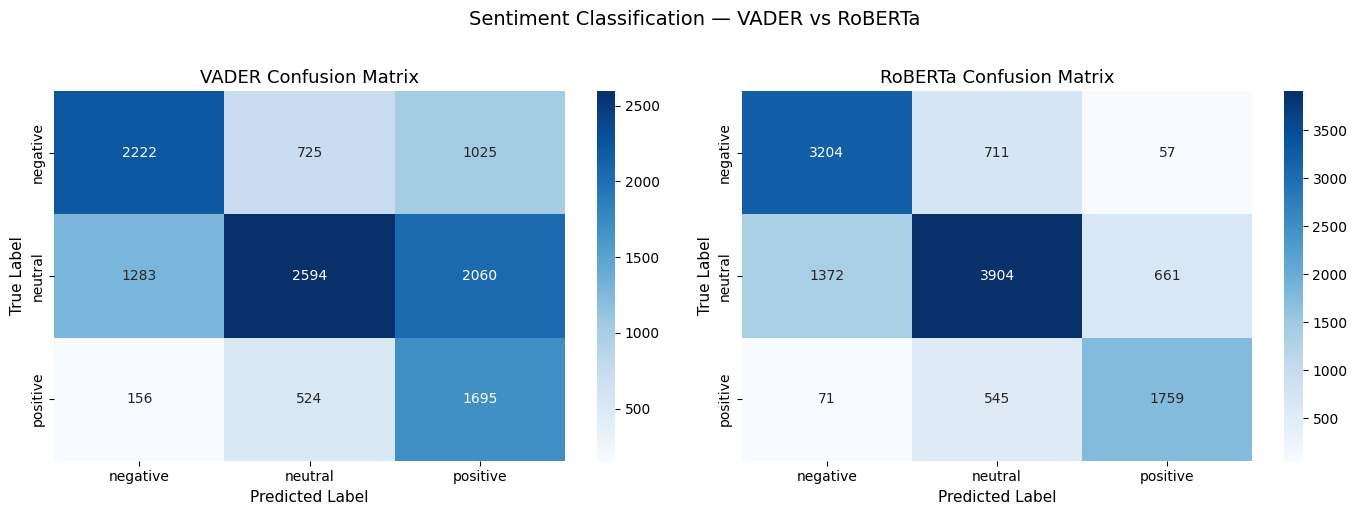

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# VADER confusion matrix
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['negative', 'neutral', 'positive'],
    yticklabels=['negative', 'neutral', 'positive'],
    ax=axes[0]
)
axes[0].set_title('VADER Confusion Matrix', fontsize=13)
axes[0].set_xlabel('Predicted Label', fontsize=11)
axes[0].set_ylabel('True Label', fontsize=11)

# RoBERTa confusion matrix
sns.heatmap(
    roberta_cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['negative', 'neutral', 'positive'],
    yticklabels=['negative', 'neutral', 'positive'],
    ax=axes[1]
)
axes[1].set_title('RoBERTa Confusion Matrix', fontsize=13)
axes[1].set_xlabel('Predicted Label', fontsize=11)
axes[1].set_ylabel('True Label', fontsize=11)

plt.suptitle('Sentiment Classification — VADER vs RoBERTa', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('../results/figures/roberta_vs_vader_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

It is evident that RoBERTa does a better job correctly classifying all sentiments.

Negative class (top row):

- VADER: 2,222 correct, 1,025 wrongly called positive
- RoBERTa: 3,204 correct, only 57 wrongly called positive, dramatically better!

Neutral class (middle row):

- VADER: 2,594 correct, badly split between negative (1,283) and positive (2,060)
- RoBERTa: 3,904 correct, much tighter errors — still leaks into negative (1,372) and positive (661) but far less

Positive class (bottom row):

- VADER: 1,695 correct, 524 called neutral
- RoBERTa: 1,759 correct, 545 called neutral

## RoBERTa Hate Detection

I now load `cardiffnlp/twitter-roberta-base-hate` — a RoBERTa model fine-tuned 
specifically for hate speech detection on Twitter data. This is the appropriate 
domain-specific model for this task.

In [16]:
hate_model_name = "cardiffnlp/twitter-roberta-base-hate"

print("Loading hate detection model...")
hate_tokenizer = AutoTokenizer.from_pretrained(hate_model_name)
hate_model = AutoModelForSequenceClassification.from_pretrained(hate_model_name)
hate_model = hate_model.to('cuda')
hate_model.eval()

print(f"Model loaded on: {next(hate_model.parameters()).device}")
print(f"Number of labels: {hate_model.config.num_labels}")
print(f"Label mapping: {hate_model.config.id2label}")

# Sanity check
test_tweets = [
    "I love everyone equally.",
    "I hate this group of people they should all leave.",
    "The weather is nice today."
]

print("\nSanity check:")
for tweet in test_tweets:
    preds, probs = predict_roberta([tweet], hate_model, hate_tokenizer, device='cuda')
    label = hate_model.config.id2label[preds[0]]
    print(f"  {tweet}")
    print(f"  → {label} (confidence: {probs[0].max():.3f})\n")

Loading hate detection model...


/home/valkeo/.local/lib/python3.10/site-packages/huggingface_hub/file_download.py:1132: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


Model loaded on: cuda:0
Number of labels: 2
Label mapping: {0: 'non-hate', 1: 'hate'}

Sanity check:
  I love everyone equally.
  → non-hate (confidence: 0.973)

  I hate this group of people they should all leave.
  → non-hate (confidence: 0.880)

  The weather is nice today.
  → non-hate (confidence: 0.914)



Interesting! The model thinks 'I hate this group of people they should all leave.' is not a hateful sentiment.

In [17]:
test_tweet = ["I hate this group of people they should all leave."]

# Manual check with explicit tokenization
encoded = hate_tokenizer(
    test_tweet,
    padding=True,
    truncation=True,
    max_length=128,
    return_tensors='pt'
)

print("Tokens:", hate_tokenizer.convert_ids_to_tokens(encoded['input_ids'][0]))

with torch.no_grad():
    outputs = hate_model(
        input_ids=encoded['input_ids'].to('cuda'),
        attention_mask=encoded['attention_mask'].to('cuda')
    )

probs = F.softmax(outputs.logits, dim=-1)
print(f"\nRaw logits: {outputs.logits}")
print(f"Probabilities: non-hate={probs[0][0]:.3f}, hate={probs[0][1]:.3f}")
print(f"Predicted: {hate_model.config.id2label[probs[0].argmax().item()]}")

Tokens: ['<s>', 'I', 'Ġhate', 'Ġthis', 'Ġgroup', 'Ġof', 'Ġpeople', 'Ġthey', 'Ġshould', 'Ġall', 'Ġleave', '.', '</s>']

Raw logits: tensor([[ 1.0387, -0.9500]], device='cuda:0')
Probabilities: non-hate=0.880, hate=0.120
Predicted: non-hate


The model has now doubled-down on it's belief that 'I hate this group of people they should all leave.' is not a hateful sentiment...

Just gonna check whether other 'hateful' sentiments are classified as hate or non-hate.

In [18]:
targeted_tweets = [
    "I hate this group of people they should all leave.",
    "All [ethnic group] people should be deported.",
    "All hispanic people should be deported.",
    "All jewish people should be deported.",
    "All white people should be deported.",
    "All asian people should be deported.",
    "All black people should be deported.",
    "All women should be deported.",
    "Women are inferior and shouldn't be allowed to work.",
    "I hate Mondays so much.",
    "These immigrants are destroying our country.",
]

print("Targeted hate speech sanity check:\n")
for tweet in targeted_tweets:
    preds, probs = predict_roberta([tweet], hate_model, hate_tokenizer, device='cuda')
    label = hate_model.config.id2label[preds[0]]
    print(f"  Tweet: {tweet}")
    print(f"  → {label} (non-hate={probs[0][0]:.3f}, hate={probs[0][1]:.3f})\n")

Targeted hate speech sanity check:

  Tweet: I hate this group of people they should all leave.
  → non-hate (non-hate=0.880, hate=0.120)

  Tweet: All [ethnic group] people should be deported.
  → non-hate (non-hate=0.632, hate=0.368)

  Tweet: All hispanic people should be deported.
  → hate (non-hate=0.407, hate=0.593)

  Tweet: All jewish people should be deported.
  → hate (non-hate=0.424, hate=0.576)

  Tweet: All white people should be deported.
  → hate (non-hate=0.294, hate=0.706)

  Tweet: All asian people should be deported.
  → hate (non-hate=0.340, hate=0.660)

  Tweet: All black people should be deported.
  → hate (non-hate=0.429, hate=0.571)

  Tweet: All women should be deported.
  → hate (non-hate=0.082, hate=0.918)

  Tweet: Women are inferior and shouldn't be allowed to work.
  → hate (non-hate=0.100, hate=0.900)

  Tweet: I hate Mondays so much.
  → non-hate (non-hate=0.939, hate=0.061)

  Tweet: These immigrants are destroying our country.
  → hate (non-hate=0.220,

### Sanity Check Conclusions

The model correctly identifies hate speech when a specific protected group is named 
with hostile intent. Confidence varies by group; gender-based hate scores highest 
(91.8%) while ethnicity-based targeting scores in the 57-70% range. This variation 
likely reflects training data distribution rather than model failure.

The placeholder [ethnic group] correctly produces uncertainty (63/37) since no real 
group is named. Generic hostility without a specific target is correctly classified 
as non-hate.

Model is working as expected. Proceeding to full inference on hate test set.

In [20]:
hate_tweets = hate_test['text'].tolist()
hate_true_labels = hate_test['label'].tolist()

# Split into batches of 32
hate_batches = [hate_tweets[i:i+32] for i in range(0, len(hate_tweets), 32)]

hate_roberta_predictions = []
hate_roberta_probs = []

print(f"Running inference on {len(hate_tweets)} tweets in {len(hate_batches)} batches...")

for i, batch in enumerate(hate_batches):
    with torch.autocast('cuda', dtype=torch.float16):
        preds, probs = predict_roberta(batch, hate_model, hate_tokenizer, device='cuda')
    hate_roberta_predictions.extend(preds)
    hate_roberta_probs.extend(probs)
    
    if i % 20 == 0:
        print(f"  Batch {i}/{len(hate_batches)}...")

# Metrics
hate_roberta_accuracy = accuracy_score(hate_true_labels, hate_roberta_predictions)
hate_roberta_f1_macro = f1_score(hate_true_labels, hate_roberta_predictions, average='macro')
hate_roberta_f1_per_class = f1_score(hate_true_labels, hate_roberta_predictions, average=None)
hate_roberta_precision = precision_score(hate_true_labels, hate_roberta_predictions, average=None)
hate_roberta_recall = recall_score(hate_true_labels, hate_roberta_predictions, average=None)
hate_roberta_cm = confusion_matrix(hate_true_labels, hate_roberta_predictions)

print(f"\nAccuracy:     {hate_roberta_accuracy:.3f}")
print(f"F1-macro:     {hate_roberta_f1_macro:.3f}")
print(f"\nF1 per class:")
print(f"  Non-hate:   {hate_roberta_f1_per_class[0]:.3f}")
print(f"  Hate:       {hate_roberta_f1_per_class[1]:.3f}")
print(f"\nPrecision per class:")
print(f"  Non-hate:   {hate_roberta_precision[0]:.3f}")
print(f"  Hate:       {hate_roberta_precision[1]:.3f}")
print(f"\nRecall per class:")
print(f"  Non-hate:   {hate_roberta_recall[0]:.3f}")
print(f"  Hate:       {hate_roberta_recall[1]:.3f}")

print(f"\nConfusion Matrix:")
print(hate_roberta_cm)

Running inference on 2970 tweets in 93 batches...
  Batch 0/93...
  Batch 20/93...
  Batch 40/93...
  Batch 60/93...
  Batch 80/93...

Accuracy:     0.577
F1-macro:     0.555

F1 per class:
  Non-hate:   0.456
  Hate:       0.654

Precision per class:
  Non-hate:   0.890
  Hate:       0.499

Recall per class:
  Non-hate:   0.306
  Hate:       0.948

Confusion Matrix:
[[ 526 1192]
 [  65 1187]]


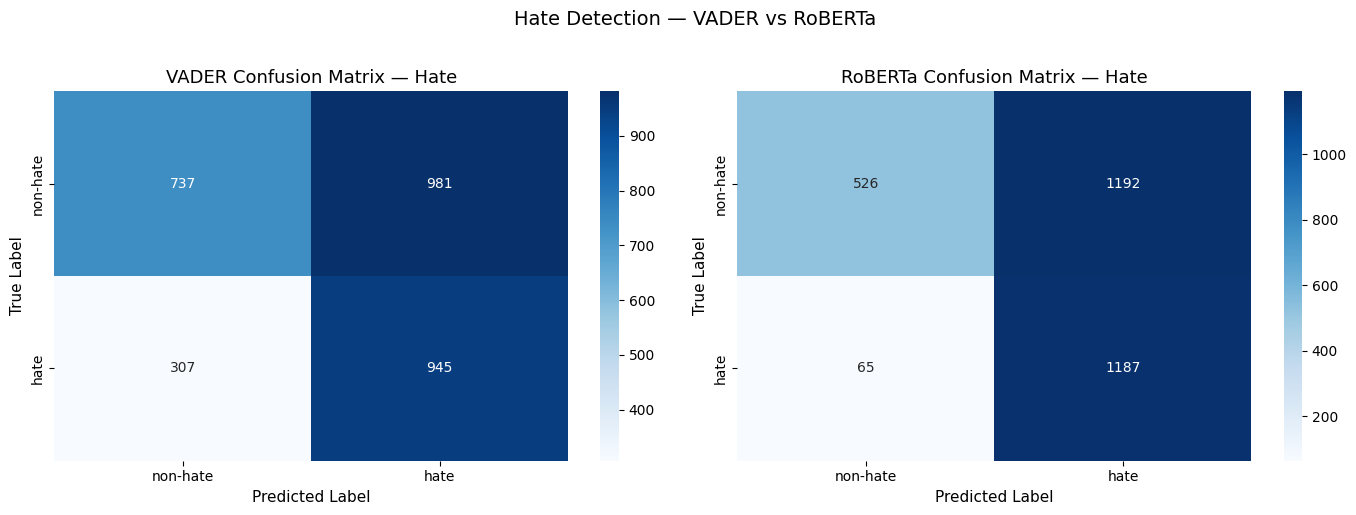

In [22]:
# Recompute VADER hate predictions for comparison
hate_vader_predictions = []
for tweet in hate_test['text']:
    scores = sia.polarity_scores(tweet)
    compound = scores['compound']
    if compound <= -0.05:
        hate_vader_predictions.append(1)
    else:
        hate_vader_predictions.append(0)

vader_hate_cm = confusion_matrix(hate_true_labels, hate_vader_predictions)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.heatmap(
    vader_hate_cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['non-hate', 'hate'],
    yticklabels=['non-hate', 'hate'],
    ax=axes[0]
)
axes[0].set_title('VADER Confusion Matrix — Hate', fontsize=13)
axes[0].set_xlabel('Predicted Label', fontsize=11)
axes[0].set_ylabel('True Label', fontsize=11)

sns.heatmap(
    hate_roberta_cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['non-hate', 'hate'],
    yticklabels=['non-hate', 'hate'],
    ax=axes[1]
)
axes[1].set_title('RoBERTa Confusion Matrix — Hate', fontsize=13)
axes[1].set_xlabel('Predicted Label', fontsize=11)
axes[1].set_ylabel('True Label', fontsize=11)

plt.suptitle('Hate Detection — VADER vs RoBERTa', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('../results/figures/roberta_vs_vader_hate_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

## VADER vs RoBERTa — Hate Detection Results

| Metric          | VADER  | RoBERTa | Change   |
|-----------------|--------|---------|----------|
| Accuracy        | 0.566  | 0.577   | +1.1%    |
| F1-macro        | 0.564  | 0.555   | -0.9%    |
| F1 Non-hate     | 0.534  | 0.456   | -7.8%    |
| F1 Hate         | 0.595  | 0.654   | +5.9%    |
| Precision Non-hate | 0.706 | 0.890 | +18.4%  |
| Recall Non-hate | 0.429  | 0.306   | -12.3%   |
| Precision Hate  | 0.491  | 0.499   | +0.8%    |
| Recall Hate     | 0.755  | 0.948   | +19.3%   |

### Key Observations

RoBERTa hate detection tells a more nuanced story than sentiment:

- Hate recall is exceptional (94.8%): RoBERTa catches nearly all actual hate 
speech, missing only 65 of 1,252 hate tweets. This is its strongest suit.

- Non-hate recall is poor (30.6%): RoBERTa is aggressively flagging non-hate 
content as hate, misclassifying 1,192 of 1,718 non-hate tweets!

- F1-macro is actually slightly worse than VADER (0.555 vs 0.564) despite being 
a domain-specific model. This is because the extreme precision/recall imbalance 
hurts the non-hate F1 significantly.

- RoBERTa hate is a high-recall, low-precision system. 
For a content moderation pipeline where missing hate is catastrophic, this is 
acceptable, catch everything and let human reviewers filter false alarms. For 
automated removal with no human review, the false alarm rate is too high!

## Stage 4: Local LLM Inference via Ollama

I use Ollama to run Llama 3 locally, which is a large language model with 8 billion parameters 
running entirely on my machine. Unlike RoBERTa which was fine-tuned specifically for 
sentiment classification, Llama 3 is a general-purpose model that I prompt to perform 
the task using natural language instructions. This is called zero-shot classification,
where the model has never been explicitly trained on our labels, it reasons about them from 
the prompt alone.

Ollama exposes Llama 3 as a local REST API on port 11434, which I call from Python 
identically to how you would call the OpenAI API. All inference happens locally,
no data leaves the machine.

### Key differences from RoBERTa:
- **No fine-tuning** — engineer a prompt instead of training
- **Structured output** —  instruct the model to return JSON so downstream code can parse it
- **Much slower** — LLMs generate tokens sequentially, unlike RoBERTa's parallel inference
- **Larger model** — 8B parameters vs RoBERTa's 125M
- **More flexible** — the same model can handle sentiment, hate detection, and NER 
  with different prompts, no retraining required

### What I measure:
- Throughput on a 100-tweet sample (full test set would take ~1 hour)
- F1-macro compared against VADER and RoBERTa baselines
- JSON parsing failure rate — how often does the model return malformed output?
- Qualitative analysis of hard cases where LLM reasoning outperforms RoBERTa

## Setup Notes
- Ollama runs as a systemd service and starts automatically on boot
- Llama 3 model is pulled once via `ollama pull llama3` or automatically via `setup_env.sh`
- Verify llama3 can be run interactively as a safety check via `ollama run llama3`
- If Ollama is unresponsive, restart with `ollama serve`

### Connecting to Ollama from Python

Call Ollama's local REST API using the `requests` library — the same pattern 
as any HTTP API call. Ollama listens on port 11434 and exposes a `/api/generate` 
endpoint that accepts a model name and prompt and streams back a response.

In [24]:
import requests
import json

def call_ollama(prompt, model='llama3', temperature=0):
    response = requests.post(
        'http://localhost:11434/api/generate',
        json={
            'model': model,
            'prompt': prompt,
            'stream': False, # wait for full response instead of streaming
            'options': {
                # Temperature controls how deterministic/random the response is. 0 = deterministic, 0.7 moderate randomness, 1.0 high randomness
                'temperature': temperature
            }
        }
    )
    # The response object has a json method that parses the response body from JSON into a python dictionary
    # pull out just the response from said dict
    return response.json()['response']

# Sanity check
result = call_ollama("Say hello in one word.")
print(f"Ollama response: {result}")

Ollama response: Hello!


In [27]:
def classify_sentiment(tweet):
    prompt = f"""You are a sentiment classifier. Classify the following tweet as positive, negative, or neutral.
    Tweet: {tweet}
    
    Respond with only a JSON object in this exact format, nothing else:
    {{"label": "positive", "confidence": "0.0", "reasoning": "brief explanation"}}
    
    The label must be exactly one of: positive, negative, neutral.
    The confidence score must be a value between 0.0 and 1.0.
    Do not include any text outside the JSON object."""

    response = call_ollama(prompt)
    return response

# Test on a few tweets
test_tweets = [
    "I love this so much!!!",
    "This is the worst thing ever.",
    "I went to the store today."
]

for tweet in test_tweets:
    result = classify_sentiment(tweet)
    print(f"Tweet: {tweet}")
    print(f"Response: {result}\n")

Tweet: I love this so much!!!
Response: {"label": "positive", "confidence": "1.0", "reasoning": "The use of 'I love this so much' is a strong expression of enthusiasm, indicating a positive sentiment."}

Tweet: This is the worst thing ever.
Response: {"label": "negative", "confidence": "1.0", "reasoning": "Strongly worded phrase with superlative 'worst'"}

Tweet: I went to the store today.
Response: {"label": "neutral", "confidence": "0.5", "reasoning": "The tweet lacks emotional language or sentiment-indicating words, making it neutral."}



In [28]:
def classify_sentiment_parsed(tweet):
    response = classify_sentiment(tweet)
    
    try:
        # Convert JSON string to a Python dictionary
        parsed = json.loads(response)
        return {
            'label': parsed['label'],
            'confidence': float(parsed['confidence']),
            'reasoning': parsed['reasoning'],
            'parse_error': False
        }
    except (json.JSONDecodeError, KeyError) as e:
        # Model returned malformed JSON, record the failure!
        return {
            'label': None,
            'confidence': None,
            'reasoning': response,  # store raw response for debugging
            'parse_error': True
        }

# Test on a hard case
hard_tweets = [
    "Oh great, another Monday.",                    # sarcasm
    "I didn't hate it.",                            # negation
    "This is not bad at all.",                      # double negation
]

for tweet in hard_tweets:
    result = classify_sentiment_parsed(tweet)
    print(f"Tweet: {tweet}")
    print(f"Label: {result['label']} (confidence: {result['confidence']})")
    print(f"Reasoning: {result['reasoning']}\n")

Tweet: Oh great, another Monday.
Label: negative (confidence: 0.8)
Reasoning: The tone is complaining and the phrase 'Oh great' has a negative connotation.

Tweet: I didn't hate it.
Label: neutral (confidence: 0.5)
Reasoning: The tweet does not express strong emotions, but it's not entirely positive either.

Tweet: This is not bad at all.
Label: positive (confidence: 0.8)
Reasoning: The tweet contains a positive phrase 'not bad at all' which indicates a favorable opinion.



### Hard Case Analysis

Llama 3 demonstrates clear advantages over VADER on linguistically complex cases:

- **Sarcasm** ("Oh great, another Monday"): correctly identified as negative 
  despite containing the positive word "great". VADER would likely predict positive.
- **Double negation** ("not bad at all"): correctly resolved to positive. 
  VADER struggles with negation chains.
- **Weak negation** ("I didn't hate it"): appropriately uncertain (0.5), 
  classified as neutral. A reasonable judgment on a genuinely ambiguous case.

The reasoning field provides interpretability that RoBERTa cannot!

### Llama 3 Zero-Shot Benchmark — 100 Tweets

I run Llama 3 on a 100-tweet sample from the sentiment test set.

I track:
- Throughput (tweets per second)
- JSON parse failure rate
- Accuracy and F1-macro vs VADER and RoBERTa baselines

In [30]:
import time

# Sample 100 tweets from sentiment test set
sample_100 = sentiment_test.sample(n=100, random_state=42)
sample_tweets = sample_100['text'].tolist()
sample_labels = sample_100['label'].tolist()

llama_predictions = []
llama_confidences = []
llama_reasonings = []
parse_errors = 0

print("Running Llama 3 zero-shot inference on 100 tweets...")
start = time.time()

for i, tweet in enumerate(sample_tweets):
    result = classify_sentiment_parsed(tweet)
    
    if result['parse_error']:
        parse_errors += 1
        llama_predictions.append(None)
    else:
        # Convert label string to integer to match dataset format
        label_map = {'negative': 0, 'neutral': 1, 'positive': 2}
        llama_predictions.append(label_map.get(result['label']))
    
    llama_confidences.append(result['confidence'])
    llama_reasonings.append(result['reasoning'])
    
    if (i + 1) % 10 == 0:
        elapsed = time.time() - start
        print(f"  {i+1}/100 tweets — {elapsed:.1f}s elapsed — {(i+1)/elapsed:.1f} tweets/sec")

total_time = time.time() - start
tps = 100 / total_time

print(f"\nTotal time: {total_time:.1f}s")
print(f"Throughput: {tps:.2f} tweets/sec")
print(f"Parse errors: {parse_errors}/100")

Running Llama 3 zero-shot inference on 100 tweets...
  10/100 tweets — 6.5s elapsed — 1.5 tweets/sec
  20/100 tweets — 12.7s elapsed — 1.6 tweets/sec
  30/100 tweets — 18.8s elapsed — 1.6 tweets/sec
  40/100 tweets — 26.0s elapsed — 1.5 tweets/sec
  50/100 tweets — 32.2s elapsed — 1.6 tweets/sec
  60/100 tweets — 38.7s elapsed — 1.5 tweets/sec
  70/100 tweets — 45.1s elapsed — 1.6 tweets/sec
  80/100 tweets — 51.2s elapsed — 1.6 tweets/sec
  90/100 tweets — 57.8s elapsed — 1.6 tweets/sec
  100/100 tweets — 63.7s elapsed — 1.6 tweets/sec

Total time: 63.7s
Throughput: 1.57 tweets/sec
Parse errors: 0/100


In [32]:
# Filter out any None predictions from parse errors
valid_indices = [i for i, p in enumerate(llama_predictions) if p is not None]
valid_predictions = [llama_predictions[i] for i in valid_indices]
valid_labels = [sample_labels[i] for i in valid_indices]

llama_accuracy = accuracy_score(valid_labels, valid_predictions)
llama_f1_macro = f1_score(valid_labels, valid_predictions, average='macro')
llama_f1_per_class = f1_score(valid_labels, valid_predictions, average=None)

print(f"Evaluated on {len(valid_predictions)}/100 tweets")
print(f"\nAccuracy:   {llama_accuracy:.3f}")
print(f"F1-macro:   {llama_f1_macro:.3f}")
print(f"\nF1 per class:")
print(f"  Negative: {llama_f1_per_class[0]:.3f}")
print(f"  Neutral:  {llama_f1_per_class[1]:.3f}")
print(f"  Positive: {llama_f1_per_class[2]:.3f}")

Evaluated on 100/100 tweets

Accuracy:   0.500
F1-macro:   0.497

F1 per class:
  Negative: 0.652
  Neutral:  0.271
  Positive: 0.568


These metrics are computed on 100 tweets, not the full 12,284 tweet test set.
A sample of 100 has high variance meaning that a few misclassifications swing F1 significantly.
VADER and RoBERTa metrics were computed on the full test set, making direct 
comparison imprecise. I treat Llama 3 numbers as indicative, not definitive.

### Llama 3 Few-Shot Prompting

I add 3 examples to the prompt — one per class — before the target tweet.
The hypothesis is that concrete examples help the model calibrate what "neutral" 
looks like in tweet context, which was the weakest class in zero-shot.

In [33]:
def classify_sentiment_fewshot(tweet):
    prompt = f"""You are a sentiment classifier. Classify tweets as positive, negative, or neutral.

    Here are some examples:
    
    Tweet: "I love this so much!!!"
    {{"label": "positive", "confidence": "1.0", "reasoning": "Strong expression of enthusiasm"}}
    
    Tweet: "This is the worst thing ever."
    {{"label": "negative", "confidence": "1.0", "reasoning": "Strongly negative superlative language"}}
    
    Tweet: "I went to the store today."
    {{"label": "neutral", "confidence": "0.9", "reasoning": "Factual statement with no emotional language"}}
    
    Now classify this tweet:
    Tweet: "{tweet}"
    
    Respond with only a JSON object in this exact format, nothing else:
    {{"label": "positive", "confidence": "0.0", "reasoning": "brief explanation"}}
    
    The label must be exactly one of: positive, negative, neutral.
    The confidence score must be a value between 0.0 and 1.0.
    Do not include any text outside the JSON object."""

    response = call_ollama(prompt)
    
    try:
        parsed = json.loads(response)
        return {
            'label': parsed['label'],
            'confidence': float(parsed['confidence']),
            'reasoning': parsed['reasoning'],
            'parse_error': False
        }
    except (json.JSONDecodeError, KeyError):
        return {
            'label': None,
            'confidence': None,
            'reasoning': response,
            'parse_error': True
        }

# Run on same 100 tweets for fair comparison
llama_fewshot_predictions = []
parse_errors_fewshot = 0

print("Running Llama 3 few-shot inference on 100 tweets...")
start = time.time()

for i, tweet in enumerate(sample_tweets):
    result = classify_sentiment_fewshot(tweet)
    
    if result['parse_error']:
        parse_errors_fewshot += 1
        llama_fewshot_predictions.append(None)
    else:
        label_map = {'negative': 0, 'neutral': 1, 'positive': 2}
        llama_fewshot_predictions.append(label_map.get(result['label']))
    
    if (i + 1) % 10 == 0:
        elapsed = time.time() - start
        print(f"  {i+1}/100 tweets — {elapsed:.1f}s elapsed — {(i+1)/elapsed:.1f} tweets/sec")

total_time_fewshot = time.time() - start
tps_fewshot = 100 / total_time_fewshot

print(f"\nTotal time: {total_time_fewshot:.1f}s")
print(f"Throughput: {tps_fewshot:.2f} tweets/sec")
print(f"Parse errors: {parse_errors_fewshot}/100")

# Metrics
valid_indices_fs = [i for i, p in enumerate(llama_fewshot_predictions) if p is not None]
valid_predictions_fs = [llama_fewshot_predictions[i] for i in valid_indices_fs]
valid_labels_fs = [sample_labels[i] for i in valid_indices_fs]

llama_fs_accuracy = accuracy_score(valid_labels_fs, valid_predictions_fs)
llama_fs_f1_macro = f1_score(valid_labels_fs, valid_predictions_fs, average='macro')
llama_fs_f1_per_class = f1_score(valid_labels_fs, valid_predictions_fs, average=None)

print(f"\nAccuracy:   {llama_fs_accuracy:.3f}")
print(f"F1-macro:   {llama_fs_f1_macro:.3f}")
print(f"\nF1 per class:")
print(f"  Negative: {llama_fs_f1_per_class[0]:.3f}")
print(f"  Neutral:  {llama_fs_f1_per_class[1]:.3f}")
print(f"  Positive: {llama_fs_f1_per_class[2]:.3f}")

Running Llama 3 few-shot inference on 100 tweets...
  10/100 tweets — 11.5s elapsed — 0.9 tweets/sec
  20/100 tweets — 16.3s elapsed — 1.2 tweets/sec
  30/100 tweets — 20.7s elapsed — 1.4 tweets/sec
  40/100 tweets — 25.6s elapsed — 1.6 tweets/sec
  50/100 tweets — 30.2s elapsed — 1.7 tweets/sec
  60/100 tweets — 34.9s elapsed — 1.7 tweets/sec
  70/100 tweets — 39.6s elapsed — 1.8 tweets/sec
  80/100 tweets — 44.2s elapsed — 1.8 tweets/sec
  90/100 tweets — 49.0s elapsed — 1.8 tweets/sec
  100/100 tweets — 53.7s elapsed — 1.9 tweets/sec

Total time: 53.7s
Throughput: 1.86 tweets/sec
Parse errors: 0/100

Accuracy:   0.650
F1-macro:   0.654

F1 per class:
  Negative: 0.727
  Neutral:  0.543
  Positive: 0.693


### Llama 3 Zero-Shot vs Few-Shot — Sentiment Results
Note that these are hardcoded values for analysis.

| Metric      | VADER  | RoBERTa | Llama 3 Zero-Shot | Llama 3 Few-Shot |
|-------------|--------|---------|-------------------|------------------|
| F1-macro    | 0.529  | 0.724   | 0.497             | **0.654**        |
| F1 Negative | 0.582  | 0.743   | 0.652             | 0.727            |
| F1 Neutral  | 0.530  | 0.704   | 0.271             | 0.543            |
| F1 Positive | 0.474  | 0.725   | 0.568             | 0.693            |
| Speed (t/s) | 18,179 | 1,797   | 1.57              | 1.86             |

*Note: Llama 3 metrics computed on 100-tweet sample. VADER and RoBERTa on full 12,284 tweet test set.*

**Key findings:**
- Few-shot prompting improved F1-macro by +15.7 points over zero-shot
- Neutral class improved most dramatically (0.271 → 0.543) — concrete examples 
  helped the model calibrate what neutral looks like in tweet context
- Few-shot Llama 3 beats VADER despite no task-specific training
- RoBERTa remains the strongest classifier at 7x higher throughput than Llama 3

Next we use Llama3 to classify tweets as hate/non-hate via zero-shot and few-shot prompting.

In [55]:
def classify_hate_llama(tweet, fewshot=False):
    if fewshot:
        prompt = f"""You are a hate speech classifier. Classify tweets as either hate or non-hate.

Hate speech is content that targets a specific person or group based on protected 
characteristics such as race, ethnicity, gender, religion, or immigration status 
with hostile or dehumanizing intent.

Here are some examples:

Tweet: "My family's idea of a snack is siopao. They really hate me."
{{"label": "non-hate", "confidence": "0.9", "reasoning": "Casual complaint with no targeted group hostility"}}

Tweet: "Women are inferior and shouldn't be allowed to work."
{{"label": "hate", "confidence": "0.9", "reasoning": "Targets women as a group with dehumanizing claim"}}

Tweet: "These immigrants are destroying our country."
{{"label": "hate", "confidence": "0.8", "reasoning": "Targets immigrants as a group with hostile framing"}}

Now classify this tweet:
Tweet: "{tweet}"

Respond with only a JSON object in this exact format, nothing else:
{{"label": "non-hate", "confidence": "0.0", "reasoning": "brief explanation"}}

The label must be exactly one of: hate, non-hate.
The confidence score must be a value between 0.0 and 1.0.
Do not include any text outside the JSON object."""

    else:
        prompt = f"""You are a hate speech classifier. Classify the following tweet as either hate or non-hate.

Hate speech is content that targets a specific person or group based on protected 
characteristics such as race, ethnicity, gender, religion, or immigration status 
with hostile or dehumanizing intent.

Tweet: {tweet}

Respond with only a JSON object in this exact format, nothing else:
{{"label": "non-hate", "confidence": "0.0", "reasoning": "brief explanation"}}

The label must be exactly one of: hate, non-hate.
The confidence score must be a value between 0.0 and 1.0.
Do not include any text outside the JSON object."""

    response = call_ollama(prompt, model='llama3')
    
    try:
        parsed = json.loads(response)
        return {
            'label': parsed['label'],
            'confidence': float(parsed['confidence']),
            'reasoning': parsed['reasoning'],
            'parse_error': False
        }
    except (json.JSONDecodeError, KeyError):
        return {
            'label': None,
            'confidence': None,
            'reasoning': response,
            'parse_error': True
        }

In [57]:
# Sample 100 tweets from hate test set
hate_sample_100 = hate_test.sample(n=100, random_state=42)
hate_sample_indices = hate_sample_100.index.tolist()
hate_sample_tweets = hate_sample_100['text'].tolist()
hate_sample_labels = hate_sample_100['label'].tolist()

print("Running Llama 3 zero-shot on 100 hate tweets...")
hate_zero_predictions = []
hate_zero_parse_errors = 0

start = time.time()
for i, tweet in enumerate(hate_sample_tweets):
    result = classify_hate_llama(tweet, fewshot=False)
    
    if result['parse_error']:
        hate_zero_parse_errors += 1
        hate_zero_predictions.append(None)
    else:
        label_map = {'non-hate': 0, 'hate': 1}
        hate_zero_predictions.append(label_map.get(result['label']))
    
    if (i + 1) % 10 == 0:
        elapsed = time.time() - start
        print(f"  {i+1}/100 — {elapsed:.1f}s — {(i+1)/elapsed:.1f} t/s")

zero_time = time.time() - start

# Metrics
valid_mask = [p is not None for p in hate_zero_predictions]
valid_preds = [p for p, m in zip(hate_zero_predictions, valid_mask) if m]
valid_labels = [l for l, m in zip(hate_sample_labels, valid_mask) if m]

zero_f1 = f1_score(valid_labels, valid_preds, average='macro')
zero_f1_per_class = f1_score(valid_labels, valid_preds, average=None)

print(f"\nZero-shot results:")
print(f"  Time: {zero_time:.1f}s — {100/zero_time:.2f} t/s")
print(f"  Parse errors: {hate_zero_parse_errors}/100")
print(f"  F1-macro: {zero_f1:.3f}")
print(f"  F1 non-hate: {zero_f1_per_class[0]:.3f}")
print(f"  F1 hate:     {zero_f1_per_class[1]:.3f}")

Running Llama 3 zero-shot on 100 hate tweets...
  10/100 — 6.7s — 1.5 t/s
  20/100 — 13.7s — 1.5 t/s
  30/100 — 20.4s — 1.5 t/s
  40/100 — 27.3s — 1.5 t/s
  50/100 — 34.1s — 1.5 t/s
  60/100 — 41.0s — 1.5 t/s
  70/100 — 48.0s — 1.5 t/s
  80/100 — 55.0s — 1.5 t/s
  90/100 — 61.7s — 1.5 t/s
  100/100 — 68.5s — 1.5 t/s

Zero-shot results:
  Time: 68.5s — 1.46 t/s
  Parse errors: 0/100
  F1-macro: 0.576
  F1 non-hate: 0.776
  F1 hate:     0.377


In [58]:
print("\nRunning Llama 3 few-shot on 100 hate tweets...")
hate_few_predictions = []
hate_few_parse_errors = 0

start = time.time()
for i, tweet in enumerate(hate_sample_tweets):
    result = classify_hate_llama(tweet, fewshot=True)
    
    if result['parse_error']:
        hate_few_parse_errors += 1
        hate_few_predictions.append(None)
    else:
        label_map = {'non-hate': 0, 'hate': 1}
        hate_few_predictions.append(label_map.get(result['label']))
    
    if (i + 1) % 10 == 0:
        elapsed = time.time() - start
        print(f"  {i+1}/100 — {elapsed:.1f}s — {(i+1)/elapsed:.1f} t/s")

few_time = time.time() - start

valid_mask_few = [p is not None for p in hate_few_predictions]
valid_preds_few = [p for p, m in zip(hate_few_predictions, valid_mask_few) if m]
valid_labels_few = [l for l, m in zip(hate_sample_labels, valid_mask_few) if m]

few_f1 = f1_score(valid_labels_few, valid_preds_few, average='macro')
few_f1_per_class = f1_score(valid_labels_few, valid_preds_few, average=None)

print(f"\nFew-shot results:")
print(f"  Time: {few_time:.1f}s — {100/few_time:.2f} t/s")
print(f"  Parse errors: {hate_few_parse_errors}/100")
print(f"  F1-macro: {few_f1:.3f}")
print(f"  F1 non-hate: {few_f1_per_class[0]:.3f}")
print(f"  F1 hate:     {few_f1_per_class[1]:.3f}")


Running Llama 3 few-shot on 100 hate tweets...
  10/100 — 5.4s — 1.8 t/s
  20/100 — 10.6s — 1.9 t/s
  30/100 — 15.8s — 1.9 t/s
  40/100 — 20.8s — 1.9 t/s
  50/100 — 26.0s — 1.9 t/s
  60/100 — 31.4s — 1.9 t/s
  70/100 — 36.6s — 1.9 t/s
  80/100 — 41.7s — 1.9 t/s
  90/100 — 46.9s — 1.9 t/s
  100/100 — 52.0s — 1.9 t/s

Few-shot results:
  Time: 52.0s — 1.92 t/s
  Parse errors: 0/100
  F1-macro: 0.739
  F1 non-hate: 0.755
  F1 hate:     0.723


In [61]:
print('Hate Dataset')
print("=" * 65)
print(f"{'Method':<25} {'F1-macro':<12} {'F1 Non-hate':<15} {'F1 Hate'}")
print("=" * 65)
print(f"{'VADER (naive)':<25} {'0.564':<12} {'0.534':<15} {'0.595'}")
print(f"{'RoBERTa ':<25} {'0.555':<12} {'0.456':<15} {'0.654'}")
print(f"{'Llama3 zero-shot':<25} {zero_f1:<12.3f} {zero_f1_per_class[0]:<15.3f} {zero_f1_per_class[1]:.3f}")
print(f"{'Llama3 few-shot':<25} {few_f1:<12.3f} {few_f1_per_class[0]:<15.3f} {few_f1_per_class[1]:.3f}")
print("=" * 65)

Hate Dataset
Method                    F1-macro     F1 Non-hate     F1 Hate
VADER (naive)             0.564        0.534           0.595
RoBERTa                   0.555        0.456           0.654
Llama3 zero-shot          0.576        0.776           0.377
Llama3 few-shot           0.739        0.755           0.723


### Gemma — Zero-Shot and Few-Shot

I repeat the same experiment with Google's Gemma 7B to compare against Llama 3 with the Sentiment dataset. We skip the Hate dataset for Gemma.
Both models receive identical prompts so any performance difference is attributable 
to the model itself, not the prompting strategy.

In [46]:
import re

def parse_llm_response(response):
    # Strip markdown code blocks if present
    cleaned = re.sub(r'```json\s*|\s*```', '', response).strip()
    
    try:
        parsed = json.loads(cleaned)
        return {
            'label': parsed['label'],
            'confidence': float(parsed['confidence']),
            'reasoning': parsed['reasoning'],
            'parse_error': False
        }
    except (json.JSONDecodeError, KeyError):
        return {
            'label': None,
            'confidence': None,
            'reasoning': response,
            'parse_error': True
        }

In [49]:
def classify_sentiment_gemma(tweet, fewshot=False):
    if fewshot:
        prompt = f"""You are a sentiment classifier. Classify tweets as positive, negative, or neutral.

        Here are some examples:
        
        Tweet: "I love this so much!!!"
        {{"label": "positive", "confidence": "1.0", "reasoning": "Strong expression of enthusiasm"}}
        
        Tweet: "This is the worst thing ever."
        {{"label": "negative", "confidence": "1.0", "reasoning": "Strongly negative superlative language"}}
        
        Tweet: "I went to the store today."
        {{"label": "neutral", "confidence": "0.9", "reasoning": "Factual statement with no emotional language"}}
        
        Now classify this tweet:
        Tweet: "{tweet}"
        
        Respond with only a JSON object in this exact format, nothing else:
        {{"label": "positive", "confidence": "0.0", "reasoning": "brief explanation"}}
        
        The label must be exactly one of: positive, negative, neutral.
        The confidence score must be a value between 0.0 and 1.0.
        Do not use markdown formatting or code blocks. Return raw JSON only.
        Do not include any text outside the JSON object."""
    else:
        prompt = f"""You are a sentiment classifier. Classify the following tweet as positive, negative, or neutral.

        Tweet: {tweet}
        
        Respond with only a JSON object in this exact format, nothing else:
        {{"label": "positive", "confidence": "0.0", "reasoning": "brief explanation"}}
        
        The label must be exactly one of: positive, negative, neutral.
        The confidence score must be a value between 0.0 and 1.0.
        Do not use markdown formatting or code blocks. Return raw JSON only.
        Do not include any text outside the JSON object."""

    response = call_ollama(prompt, model='gemma')
    return parse_llm_response(response)

In [50]:
def run_benchmark(classify_fn, tweets, labels, model_name):
    predictions = []
    parse_errors = 0
    
    print(f"Running {model_name} inference on 100 tweets...")
    start = time.time()
    
    for i, tweet in enumerate(tweets):
        result = classify_fn(tweet)
        
        if result['parse_error']:
            parse_errors += 1
            predictions.append(None)
        else:
            label_map = {'negative': 0, 'neutral': 1, 'positive': 2}
            predictions.append(label_map.get(result['label']))
        
        if (i + 1) % 10 == 0:
            elapsed = time.time() - start
            print(f"  {i+1}/100 — {elapsed:.1f}s — {(i+1)/elapsed:.1f} t/s")
    
    total_time = time.time() - start
    tps = 100 / total_time
    
    valid_indices = [i for i, p in enumerate(predictions) if p is not None]
    valid_preds = [predictions[i] for i in valid_indices]
    valid_labs = [labels[i] for i in valid_indices]
    
    accuracy = accuracy_score(valid_labs, valid_preds)
    f1 = f1_score(valid_labs, valid_preds, average='macro')
    f1_classes = f1_score(valid_labs, valid_preds, average=None)
    
    print(f"\nTotal time: {total_time:.1f}s")
    print(f"Throughput: {tps:.2f} t/s")
    print(f"Parse errors: {parse_errors}/100")
    print(f"Accuracy: {accuracy:.3f}")
    print(f"F1-macro: {f1:.3f}")
    print(f"F1 per class: neg={f1_classes[0]:.3f} neu={f1_classes[1]:.3f} pos={f1_classes[2]:.3f}")
    
    return {
        'tps': tps,
        'parse_errors': parse_errors,
        'accuracy': accuracy,
        'f1_macro': f1,
        'f1_per_class': f1_classes
    }

In [53]:
# Run Gemma zero-shot
gemma_zero_results = run_benchmark(
    lambda t: classify_sentiment_gemma(t, fewshot=False),
    sample_tweets, sample_labels, "Gemma zero-shot"
)

Running Gemma zero-shot inference on 100 tweets...
  10/100 — 43.0s — 0.2 t/s
  20/100 — 81.0s — 0.2 t/s
  30/100 — 120.2s — 0.2 t/s
  40/100 — 159.1s — 0.3 t/s
  50/100 — 192.2s — 0.3 t/s
  60/100 — 230.3s — 0.3 t/s
  70/100 — 274.4s — 0.3 t/s
  80/100 — 311.5s — 0.3 t/s
  90/100 — 352.3s — 0.3 t/s
  100/100 — 391.4s — 0.3 t/s

Total time: 391.4s
Throughput: 0.26 t/s
Parse errors: 0/100
Accuracy: 0.430
F1-macro: 0.394
F1 per class: neg=0.571 neu=0.082 pos=0.529


In [54]:
# Run Gemma few-shot
gemma_few_results = run_benchmark(
    lambda t: classify_sentiment_gemma(t, fewshot=True),
    sample_tweets, sample_labels, "Gemma few-shot"
)

Running Gemma few-shot inference on 100 tweets...
  10/100 — 228.4s — 0.0 t/s
  20/100 — 473.6s — 0.0 t/s
  30/100 — 783.4s — 0.0 t/s
  40/100 — 1069.5s — 0.0 t/s
  50/100 — 1353.4s — 0.0 t/s
  60/100 — 1409.8s — 0.0 t/s
  70/100 — 1425.0s — 0.0 t/s
  80/100 — 1438.2s — 0.1 t/s
  90/100 — 1471.7s — 0.1 t/s
  100/100 — 1493.2s — 0.1 t/s

Total time: 1493.2s
Throughput: 0.07 t/s
Parse errors: 0/100
Accuracy: 0.500
F1-macro: 0.490
F1 per class: neg=0.652 neu=0.259 pos=0.560


### Gemma vs Llama 3 Conclusion

Gemma performed comparably to Llama 3 on classification quality but at 
approximately 20x lower throughput on the same hardware (RTX 3080). For 
local inference on consumer GPUs, Llama 3 is the clearly superior choice. 
Gemma's architecture may be better optimized for different hardware configurations.
Given the impractical inference speed, Gemma is excluded from the final 
model comparison table.

## Stage 4: Latency Analysis & Cost/Speed Tradeoff

### Benchmark Results (100-tweet sample)

| Model | Prompting | Tweets/sec | Sec/tweet | Parse Errors |
|-------|-----------|------------|-----------|--------------|
| Llama 3 | Zero-shot | 1.57 | 0.64s | 0/100 |
| Llama 3 | Few-shot | 1.86 | 0.54s | 0/100 |
| Gemma | Zero-shot | 0.23 | 4.35s | 0/100* |
| Gemma | Few-shot | 0.07 | 14.93s | 0/100 |

*Parse errors fixed via markdown stripping — Gemma wraps JSON in code blocks 
regardless of prompt instructions, requiring post-processing.

### When an LLM IS worth the latency

- **Hard linguistic cases**: sarcasm, negation, irony, culturally specific language. 
Our hard case analysis showed Llama 3 correctly identifying "Oh great, another Monday" 
as negative (sarcasm) and "not bad at all" as positive (double negation) — cases where 
VADER fails and RoBERTa may struggle without fine-tuning on such examples.

- **Interpretability requirements**: the reasoning field provides human-readable 
explanations for every classification. No other model in our pipeline can do this. 
For high-stakes decisions (content moderation appeals, legal review) this 
interpretability may justify the latency cost.

- **Low volume, high accuracy requirements**: at 1.57 tweets/sec, Llama 3 can process 
~135,000 tweets per day. For applications where accuracy matters more than throughput 
and volume is moderate, this is acceptable.

- **No labeled training data available**: few-shot prompting requires only 3 examples 
per class. RoBERTa requires thousands of labeled examples for fine-tuning. For new 
domains where labeled data doesn't exist yet, LLMs provide immediate value.

### When an LLM is NOT worth the latency

- **High volume, real-time applications**: social media platforms processing millions 
of posts per hour cannot use Llama 3 at 1.57 tweets/sec. RoBERTa at 1,797 tweets/sec 
is the right tool.

- **Cost-sensitive production**: running a local 8B parameter model requires a 
dedicated GPU. At scale in the cloud, GPU inference costs multiply rapidly. RoBERTa 
can run on CPU in a pinch; Llama 3 cannot practically.

- **Gemma specifically**: at 0.07 tweets/sec on an RTX 3080, Gemma is impractical 
for any production use case on consumer hardware. Llama 3 dominates on both speed 
and quality on this hardware configuration.